# How to Use the Cutout Manager Object

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.visualization import simple_norm

In [2]:
cd ../smart-plotters

/blue/adamginsburg/savannahgramze/cloudc/smart-plotters/smart-plotters


In [3]:
import cutout_plot
from cutout_plot import Cutout

In [4]:
cd tutorials/

[Errno 2] No such file or directory: 'tutorials/'
/blue/adamginsburg/savannahgramze/cloudc/smart-plotters/smart-plotters


## Using Cutout

Choose a central coordinate and the size of the cutout.

In [5]:
position = SkyCoord('17:46:21.4669695284', '-28:35:38.1118497742', unit=(u.hourangle, u.deg))
l = 1 * u.arcmin
w = 1 * u.arcmin

The Cutout uses `astropy.nddata.Cutout2D`. Initialize the Cutout object.

In [6]:
cutout = Cutout(position, l, w)

You can now use any fits or casa file overlapping with the position to get a cutout around it. 

In [7]:
fn = '/orange/adamginsburg/cmz/glimpse_data/GLM_00000+0000_mosaic_I4.fits'
cutout_I4 = cutout.get_cutout(fn)

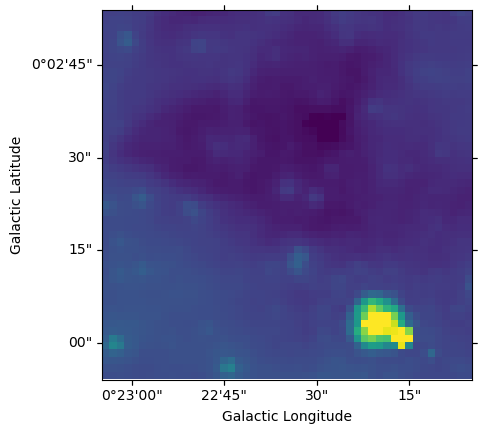

In [8]:
ax = plt.subplot(projection=cutout_I4.wcs)
norm = simple_norm(cutout_I4.data, 'sqrt', percent=99.)
im = ax.imshow(cutout_I4.data, origin='lower', cmap='viridis', norm=norm)
ax.set_xlabel('Galactic Longitude')
ax.set_ylabel('Galactic Latitude')

You can also make an rgb image easily. `get_cutout_rgb` returns a 3-dimensional array that makes an rgb image and a WCS.

In [9]:
red_fn = '/orange/adamginsburg/cmz/glimpse_data/GLM_00000+0000_mosaic_I4.fits'
green_fn = '/orange/adamginsburg/cmz/glimpse_data/GLM_00000+0000_mosaic_I3.fits'
blue_fn = '/orange/adamginsburg/cmz/glimpse_data/GLM_00000+0000_mosaic_I1.fits'

cutout_rgb, rgb_wcs = cutout.get_cutout_rgb(red_fn, green_fn, blue_fn)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


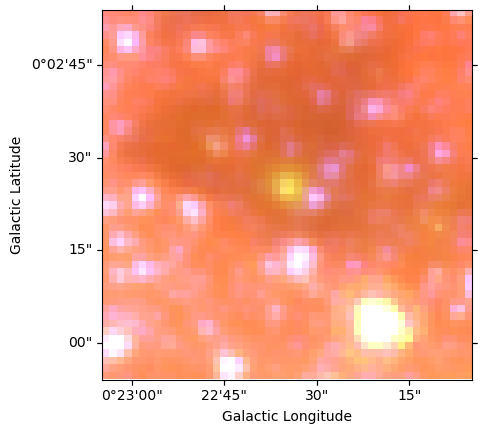

In [10]:
ax = plt.subplot(projection=rgb_wcs)
im = ax.imshow(cutout_rgb)
ax.set_xlabel('Galactic Longitude')
ax.set_ylabel('Galactic Latitude')

Change things about your cutout object. Try to make rgb images with different initial WCSs. 

In [30]:
cutout.l = 50*u.arcsec
cutout.w = 25*u.arcsec

red_fn = '/orange/adamginsburg/jwst/cloudc/alma/ACES/uid___A001_X15a0_X1a8.s36_0.Sgr_A_star_sci.spw33_35.cont.I.iter1.image.tt0'
green_fn = '/orange/adamginsburg/jwst/cloudc/images/F405_reproj_merged-fortricolor.fits'
blue_fn = '/orange/adamginsburg/cmz/glimpse_data/GLM_00000+0000_mosaic_I1.fits'

In [31]:
cutout_B3 = cutout.get_cutout(red_fn, format='casa')
cutout_rgb, rgb_wcs = cutout.get_cutout_rgb(red_fn, green_fn, blue_fn, rmax=cutout_B3.data.max()/2)

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/casa_formats_io/casa_dask.py:247: RuntimeWarning: divide by zero encountered in scalar remainder
  factors = [f for f in range(stacks[dim] + 1) if stacks[dim] % f == 0]
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/casa_formats_io/casa_dask.py:247: RuntimeWarning: divide by zero encountered in scalar remainder
  factors = [f for f in range(stacks[dim] + 1) if stacks[dim] % f == 0]


/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/casa_formats_io/casa_dask.py:247: RuntimeWarning: divide by zero encountered in scalar remainder
  factors = [f for f in range(stacks[dim] + 1) if stacks[dim] % f == 0]


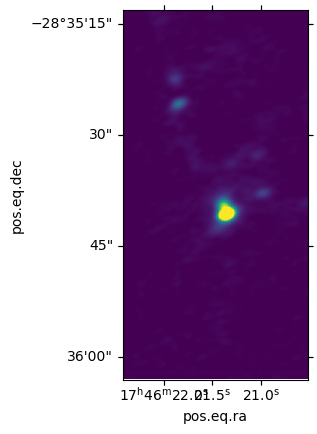

In [32]:
cutout_B3 = cutout.get_cutout(red_fn, format='casa')

ax = plt.subplot(projection=cutout_B3.wcs)
im = ax.imshow(cutout_B3.data, origin='lower', cmap='viridis', vmax=cutout_B3.data.max()/3, vmin=0)

You might see strange behavior when mixing images with different coordinate systems. `get_cutout_rgb` reprojects the images after making the cutouts to go faster.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)
/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


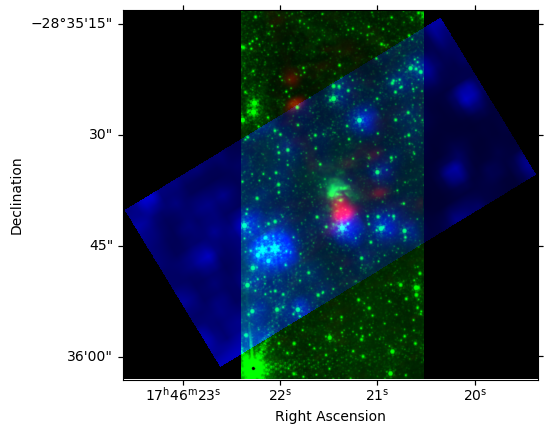

In [33]:
ax = plt.subplot(projection=rgb_wcs)
im = ax.imshow(cutout_rgb)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')